In [2]:
%load_ext autoreload
%autoreload 2

# IMPORTS

In [3]:
# Project setup
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [4]:
import warnings

import joblib

import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
)

# import sklearn
# sklearn.set_config(display="text")    # disable HTML charts and leave compact text

from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
)
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

from src.config import HEATMAP_CMAP, RANDOM_STATE
from src.evaluation import ResultsTable, evaluate_model, plot_roc_curve
from src.preprocessing import (
    create_pipeline,
    prepare_data,
    prepare_features,
    prepare_target,
)

# settings
warnings.filterwarnings('ignore', category=UserWarning)

# Traditional Machine Learning Models

This notebook focuses on traditional machine learning models. The BERT model is presented separately in 05_bert.ipynb because it requires a different preprocessing and training pipeline.

#  Data loading and preparation

In [5]:
data_path = project_root / 'data' / 'Airline_review.csv'
raw_df = pd.read_csv(data_path)

# remove duplicate reviews
raw_df = raw_df.drop_duplicates(
    subset=raw_df.columns.drop('Unnamed: 0'),
    ignore_index=True
)

# split the raw data into training-validation and test sets (80/20)
train_val_df, test_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=raw_df['Recommended']
)

# split the training-validation data into training and validation sets (80/20)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df['Recommended']
)

In [6]:
# columns to remove before modeling
cols_to_drop = [
    'Unnamed: 0',
    'Review Date',
    'Verified',
    'Route',
    'Airline Name',
    'Overall_Rating',
    'Aircraft',
    'Date Flown'
]

# data preparation
train_df = prepare_data(train_df, cols_to_drop)
val_df = prepare_data(val_df, cols_to_drop)
test_df = prepare_data(test_df, cols_to_drop)

# target preparation
train_df = prepare_target(train_df)
val_df = prepare_target(val_df)
test_df = prepare_target(test_df)

In [7]:
# feature preparation
X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)
X_test, y_test = prepare_features(test_df)

# LinearSVC

**LinearSVC** was selected because it is one of the most widely used algorithms for text classification. It is particularly well suited for high-dimensional sparse feature representations, such as **TF-IDF**, while remaining computationally efficient.

In [ ]:
linearSVC_model = create_pipeline(
    LinearSVC(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
)

linearSVC_model.fit(X_train, y_train)

In [8]:
linearSVC_metrics = evaluate_model(linearSVC_model, X_train, y_train, X_val, y_val)


=== LinearSVC ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2440
           1       0.89      0.85      0.87      1248

    accuracy                           0.92      3688
   macro avg       0.91      0.90      0.90      3688
weighted avg       0.91      0.92      0.91      3688

Confusion matrix (validation):
[[2315  125]
 [ 188 1060]]
Train F1: 0.9989
Validation F1: 0.8714
Train AUROC: 1.0000
Validation AUROC: 0.9674


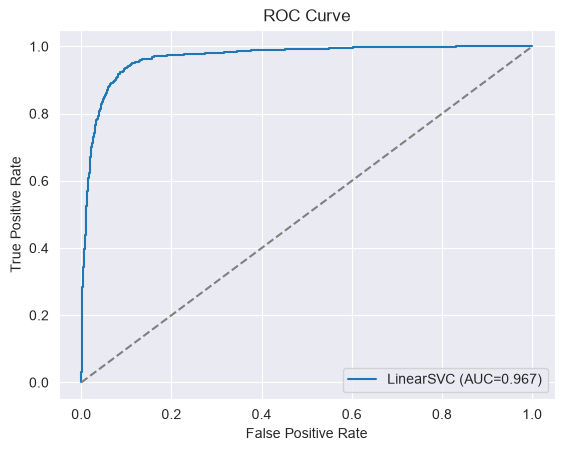

In [9]:
plot_roc_curve(linearSVC_model, X_val, y_val)

In [10]:
linearSVC_metrics['Configuration'] = 'max_iter=1000, TF-IDF'

In [11]:
model_results = ResultsTable.load('../models/model_results.csv')

In [12]:
model_results.add_result(linearSVC_metrics)
model_results.save()

In [13]:
model_results.display()

,Model,Configuration,Train_F1,Val_F1,Train_AUROC,Val_AUROC
0,LogisticRegression,"max_iter=1000, TF-IDF: ngram_range=(1,2), min_df=2",0.9069,0.8521,0.9824,0.9638
1,LinearSVC,"max_iter=1000, TF-IDF",0.9989,0.8714,1.0000,0.9674


Among the evaluated models, **LinearSVC** demonstrates the best validation performance. Compared with the baseline **Logistic Regression** model, it achieves higher `F1-score` (0.8714) and `ROC-AUC` (0.9674) while using the same text features. Although the model shows signs of overfitting on the training data, it generalizes well to the validation set and currently provides the strongest results.

# LightGBM

**LightGBM** was chosen as a tree-based gradient boosting model. Unlike linear models, it is able to learn nonlinear decision boundaries, making it a useful alternative for comparison and helping evaluate whether a more complex model provides better performance on this task.

In [ ]:
lgbm_model = create_pipeline(
    LGBMClassifier(
        random_state=RANDOM_STATE,
    ),
)

lgbm_model.fit(X_train, y_train)

In [15]:
lgbm_metrics = evaluate_model(lgbm_model, X_train, y_train, X_val, y_val)


=== LGBMClassifier ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2440
           1       0.87      0.84      0.85      1248

    accuracy                           0.90      3688
   macro avg       0.89      0.89      0.89      3688
weighted avg       0.90      0.90      0.90      3688

Confusion matrix (validation):
[[2278  162]
 [ 203 1045]]
Train F1: 0.9426
Validation F1: 0.8513
Train AUROC: 0.9941
Validation AUROC: 0.9623


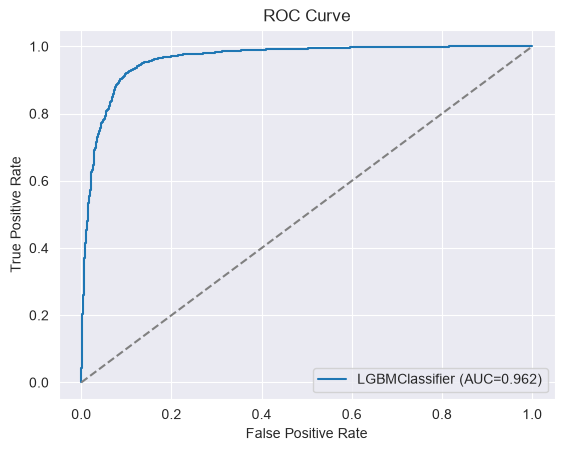

In [16]:
plot_roc_curve(lgbm_model, X_val, y_val)

In [17]:
lgbm_metrics['Configuration'] = 'TF-IDF'

In [18]:
model_results.add_result(lgbm_metrics)
model_results.save()

In [19]:
model_results.display()

,Model,Configuration,Train_F1,Val_F1,Train_AUROC,Val_AUROC
0,LogisticRegression,"max_iter=1000, TF-IDF: ngram_range=(1,2), min_df=2",0.9069,0.8521,0.9824,0.9638
1,LinearSVC,"max_iter=1000, TF-IDF",0.9989,0.8714,1.0000,0.9674
2,LGBMClassifier,TF-IDF,0.9426,0.8513,0.9941,0.9623


**LightGBM** achieved a similar validation performance compared to **Logistic Regression**, with a validation `F1-score` of 0.851 and `ROC-AUC` of 0.962. However, the model showed a larger gap between training and validation metrics, suggesting some overfitting. Although the model produced strong results overall, its validation `F1-score` and `ROC-AUC` were slightly lower than those of **LinearSVC**.

---

**LinearSVC** achieved the best validation performance among all evaluated models. Therefore, the next step is to optimize its hyperparameters using **Optuna** in order to determine whether its performance can be improved further.

# Hyperparameter optimization using Optuna

**Optuna** was selected for hyperparameter optimization because it performs an adaptive search rather than evaluating every parameter combination. Compared with Grid Search, it is generally more computationally efficient while still finding strong hyperparameter configurations. This makes it a practical choice for iterative model development.

Since the dataset contains a moderate class imbalance (approximately 66% negative vs. 34% positive reviews), `class weighting` will included in the **Optuna** search space to evaluate whether emphasizing the minority class improves classification performance.

In [8]:
def objective(trial):

    C = trial.suggest_float(
        'C',
        1e-3,
        10,
        log=True
    )

    loss = trial.suggest_categorical(
        'loss',
        ['hinge', 'squared_hinge']
    )

    class_weight = trial.suggest_categorical(
        'class_weight',
        [None, 'balanced']
    )

    model = create_pipeline(
        LinearSVC(
            C=C,
            loss=loss,
            dual='auto',
            class_weight=class_weight,
            random_state=RANDOM_STATE
        )
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    return score.mean()

The search space consisted of only three hyperparameters, and the optimization history showed that the objective value stabilized after relatively few trials. Therefore, 30 optimization trials were considered sufficient.

In [ ]:
# create and run Optuna study
study = optuna.create_study(
    direction='maximize',
    study_name='linearsvc',
    storage='sqlite:///../models/linearsvc_optuna.db',
    load_if_exists=True
)

study.optimize(objective, n_trials=30)

In [9]:
# study loading
study = optuna.load_study(
    study_name='linearsvc',
    storage='sqlite:///../models/linearsvc_optuna.db'
)

In [10]:
best_params = study.best_params
best_value = study.best_value

In [23]:
print("Best parameters:", best_params)
print("Best F1-score (validation):", best_value)

Best parameters: {'C': 0.9813625568604659, 'loss': 'hinge', 'class_weight': 'balanced'}
Best F1-score (validation): 0.8770784143085603


In [24]:
fig = plot_optimization_history(study)
fig.show()

In [25]:
fig2 = plot_param_importances(study)
fig2.show()

According to the parameter importance analysis, `C` is the most influential hyperparameter, accounting for almost all of the observed variation in model performance. The effects of `loss` and `class_weight` are comparatively small, indicating that the model is relatively insensitive to these settings within the tested search space.
This result is consistent with the optimization history, where performance stabilized after relatively few trials, suggesting that the search space for this model is fairly simple.

In [ ]:
final_model = create_pipeline(
    LinearSVC(
        **best_params,
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
)

final_model.fit(X_train, y_train)

In [27]:
final_metrics = evaluate_model(final_model, X_train, y_train, X_val, y_val)


=== LinearSVC ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2440
           1       0.87      0.89      0.88      1248

    accuracy                           0.92      3688
   macro avg       0.91      0.91      0.91      3688
weighted avg       0.92      0.92      0.92      3688

Confusion matrix (validation):
[[2278  162]
 [ 139 1109]]
Train F1: 0.9670
Validation F1: 0.8805
Train AUROC: 0.9966
Validation AUROC: 0.9671


In [28]:
final_metrics['Configuration'] = "Final Model. C=0.7363, loss='hinge', class_weight='balanced'"

In [30]:
model_results.add_result(final_metrics)
model_results.save()

In [31]:
model_results.display()

,Model,Configuration,Train_F1,Val_F1,Train_AUROC,Val_AUROC
0,LogisticRegression,"max_iter=1000, TF-IDF: ngram_range=(1,2), min_df=2",0.9069,0.8521,0.9824,0.9638
1,LinearSVC,"max_iter=1000, TF-IDF",0.9989,0.8714,1.0000,0.9674
2,LGBMClassifier,TF-IDF,0.9426,0.8513,0.9941,0.9623
3,LinearSVC,"Final Model. C=0.7363, loss='hinge', class_weight='balanced'",0.9670,0.8805,0.9966,0.9671


| Model | Configuration | Train_F1 | Val_F1 | Train_AUROC | Val_AUROC |
| :--- | :--- | :---: | :---: | :---: | :---: |
| LogisticRegression | max_iter=1000, TF-IDF: ngram_range=(1,2), min_df=2 | 0.9069 | 0.8521 | 0.9824 | 0.9638 |
| LinearSVC | max_iter=1000, TF-IDF | 0.9989 | 0.8714 | 1.0000 | 0.9674 |
| LGBMClassifier | TF-IDF | 0.9426 | 0.8513 | 0.9941 | 0.9623 |
| LinearSVC | Final Model. C=0.7363, loss='hinge', class_weight='balanced' | 0.9670 | 0.8805 | 0.9966 | 0.9671 |

The comparison indicates that **LinearSVC** provides the best balance between precision and recall on the validation set. Hyperparameter optimization with **Optuna** further improved its validation `F1-score` from 0.8714 to 0.8805, while maintaining a high `ROC-AUC`. Therefore, the optimized LinearSVC model was selected as the final model for the subsequent analysis.

### Final Evaluation on the Test Set

The optimized **LinearSVC** model was selected as the final model based on its performance on the validation set. Before the final evaluation, the model was retrained using the combined training and validation datasets to maximize the amount of data available for learning. The independent test set, which had not been used during model selection or hyperparameter tuning, was then used to obtain the final performance estimates.

In [ ]:
# combine training and validation data
train_final = pd.concat([train_df, val_df], ignore_index=True)

# prepare features
X_final, y_final = prepare_features(train_final)

# retrain the final model on all available training data
final_model.fit(X_final, y_final)

In [15]:
# path to the deployment/
deployment_dir = project_root / 'deployment'
deployment_dir.mkdir(parents=True, exist_ok=True)

# model storage
joblib.dump(final_model, deployment_dir / 'airline_pipeline.pkl')

['G:\\Predicting Airline Recommendations\\deployment\\airline_pipeline.pkl']

In [33]:
# Final evaluation on the independent test set
final_test_metrics = evaluate_model(final_model, X_final, y_final, X_test, y_test, dataset_name='test')


=== LinearSVC ===
Classification report (test):
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3051
           1       0.85      0.89      0.87      1560

    accuracy                           0.91      4611
   macro avg       0.90      0.90      0.90      4611
weighted avg       0.91      0.91      0.91      4611

Confusion matrix (test):
[[2805  246]
 [ 174 1386]]
Train F1: 0.9666
Test F1: 0.8684
Train AUROC: 0.9967
Test AUROC: 0.9587


In [34]:
final_test_metrics['Configuration'] = 'Final Model. Test set.'

In [36]:
test_set_results = ResultsTable()
test_set_results.add_result(final_test_metrics)
test_set_results.save()

In [37]:
test_set_results.display()

,Model,Configuration,Train_F1,Val_F1,Train_AUROC,Val_AUROC
0,LinearSVC,Final Model. Test set.,0.9666,0.8684,0.9967,0.9587


| Model | Configuration | Train_F1 | Val_F1 | Train_AUROC | Val_AUROC |
| :--- | :--- | :---: | :---: | :---: | :---: |
| LinearSVC | Final Model. Test set. | 0.9666 | 0.8684 | 0.9967 | 0.9587 |

The optimized **LinearSVC** achieved a `Train F1-score` of 0.9666 and a `Test F1-score` of 0.8684. The difference between the training and test performance indicates that the model still exhibits some degree of overfitting, although hyperparameter tuning reduced this effect compared to the initial LinearSVC model.

Despite this performance gap, the model maintains strong results on the independent test set, achieving an `F1-score` of 0.8684 and an `AUROC` of 0.9587. The model generalizes well to previously unseen data.

These results indicate that further improvements are unlikely to come from additional hyperparameter tuning alone. Instead, future performance gains would more likely require changes to the feature representation or the use of more expressive text models.

# Analysis of Results

## ROC Curve

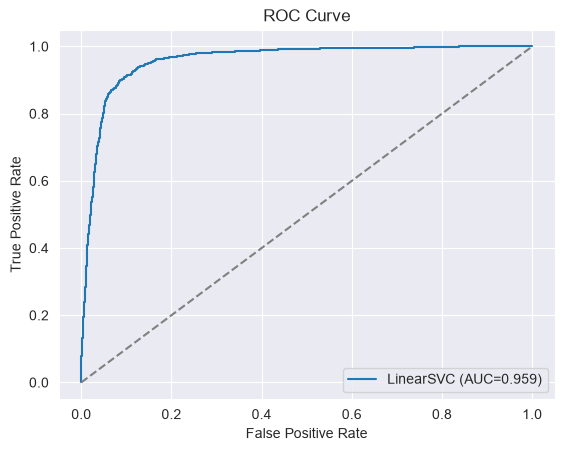

In [38]:
plot_roc_curve(final_model, X_test, y_test)

- The `ROC curve` is concentrated near the upper-left corner, indicating that the model achieves a high true positive rate while keeping the false positive rate relatively low.
- The `AUROC score` of 0.959 confirms that the classifier has a strong ability to distinguish between recommended and non-recommended reviews.

Overall, the `ROC curve` is consistent with the evaluation metrics and demonstrates good generalization on the independent test set.

## Confusion Matrix

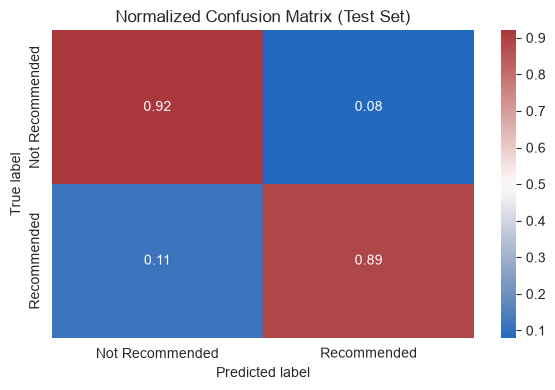

In [41]:
# confusion matrix & visualization
cm = confusion_matrix(y_test, final_model.predict(X_test), normalize='true').round(2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap=HEATMAP_CMAP,
    xticklabels=['Not Recommended', 'Recommended'],
    yticklabels=['Not Recommended', 'Recommended']
)

plt.title('Normalized Confusion Matrix (Test Set)')
plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()
plt.savefig(
    project_root / 'images' / 'confusion_matrix.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

The confusion matrix shows that the model performs slightly better on the **Not Recommended** class than on the **Recommended** class:
 - 92% of the non-recommended reviews are classified correctly.
 - 89% of the recommended reviews are classified correctly.

This is expected, since the negative class is larger (about 66% of the sample).

The recall of the two classes is fairly balanced. The difference is only about 3%, meaning the model does not have a strong tendency to favor one class.

The largest source of errors is ~~false negatives~~, where 11% of recommended reviews are predicted as non-recommended. This suggests that reviews containing both positive and negative opinions may be more difficult for the TF-IDF-based LinearSVC model to classify correctly.

## Error Analysis

In [42]:
# DataFrame for analysis (raw Review text + actual recommendation + predict recommendation)
test_result_df = pd.DataFrame({
    'Review': test_df['Review'],
    'actual_rec': test_df['Recommended_num'],
    'predicted_rec': final_model.predict(X_test)
}, index=test_df.index)

# false positive DF
false_positive_df = test_result_df[(test_result_df['actual_rec'] == 0) & (test_result_df['predicted_rec'] == 1)]
# false negative DF
false_negative_df = test_result_df[(test_result_df['actual_rec'] == 1) & (test_result_df['predicted_rec'] == 0)]

In [43]:
with pd.option_context('display.max_colwidth', None):
    display(false_positive_df.sample(3))

,Review,actual_rec,predicted_rec
20468,"Having spent 4 days of my holiday in Bangkok Phuket Hospital with an attack of Bronchitis I was pleased to be returning once again to Singapore. Whilst at Phuket I arranged and paid for a wheelchair to be provided and the service I received from the staff at Phuket Airport was excellent. I was assured that a wheelchair would be awaiting me upon my arrival at Changi. Unfortunately when we landed there was no wheelchair to be seen. A female member of the cabin crew ran off to find the chair whilst I hobbled as best I could. Half way to arrivals I met the cabin crew member, now running the other way with the chair which she helped me into and another passenger then took over and wheeled me right through to the baggage area.\r\n\r\n",0,1
22861,"My family and I travelled from Beijing To Taipei Songshan (TSA), and Taipei TPE to Beijing, both times with Xiamen Airlines in Economy class. The Good - compared to other Chinese airlines, we found the food and drinks service to be much better. The legroom on the Boeing 787 from PEK to XMN and vice-versa was very good, and the staff were friendly. An OK selection of IFE was provided on the 787 including a range of English speaking movies and many games. On 3 of the 4 flights the kids were handed an activity pack which they enjoyed playing (for about 10 minutes). The Bad - legroom on the 737 between Xiamen and Taiwan was poor. Transferring in Xiamen in both directions was ridiculous. When we checked in at Beijing, our bags were tagged through to Taipei, however we were advised that we had to go to a separate counter at Xiamen to get our boarding passes for the flight from Xiamen to Tiapei. It was not easy to find where this was once we got to Xiamen, there were no instructions nor staff to assist. Once we found the counter we were told that it didn’t open until 2 hours before the flight (we had a 3 hour layover), and there was nowhere available to sit and wait. Taking this in our stride, it was like a “red rag to a bull” when as soon as we boarded the flight to Taipei they showed us a video promoting how good Skyteam was, with their “Seamless transfer service”. It was worse when returning from Taipei. The bags could only be tagged to Xiamen, and boarding passes could only be provided to Xiamen. There was no specific transfer facility for connecting passengers that we could use to re-check bags onwards to Beijing, and no instructions whatsoever provided to assist in the transfer. Fortunately we live in mainland China so could find our way around the system, however it would have been utterly confusing for passengers who had never been to China before, with no assistance provided. If Xiamen Airlines has aspirations of being a true regional and international player, it needs to revisit its transfer services through Xiamen and replicate those of other successful airlines in performing transfers. Its part-parent airline China Southern does a dramatically better job handling passengers through Guangzhou.",0,1
13778,"Makassar to Singapore via Jakarta. Expensive baggage price, and a crowded flight, The check-in took around 50 minutes, quite upset with the check-in service, but the staff is trying to do their best and help us.",0,1


In [44]:
with pd.option_context('display.max_colwidth', None):
    display(false_negative_df.sample(3))

,Review,actual_rec,predicted_rec
7043,"I booked a flight from Guangzhou to London on 14 September 2022. On the morning of 14 September, I received a call that my seat had been canceled. I was so angry and confused, so I went to the airport after I got the call. I arrived at the airport and spoke to the duty manager at the check-in desk. I was told that there were 4 passengers who have the same problem as me and he could help me to see if anyone cancel his seat before the departure so that I could get on the flight. I was so lucky that someone canceled the tickets and I successfully boarded the flight. I appreciate the staff help.",1,0
12774,"KLM from Tel Aviv to Amsterdam, direct, with their typical plane for this season of travel on this line, the Boeing 777-200ER. The flight was delayed by around one hour, it was the infamous day of July 5-6 where Schiphol had a severe storm that caused the delay and cancellation of hundreds of flights. Ours was luckily delayed only by one hour because the flight before departed later from Amsterdam. Boarding was not done using zones. People started gathering around the gate standing around 20 minutes before boarding even started. I The flight itself was pretty chill, the crew was very professional and comforting. The breakfast that was given was fruit salad, yogurt and a hot drink. It was okay for an early morning flight. Landing at Schiphol was smooth. My only complaint would be the width of Economy class seats. I am no small person, but also not super large. And yet I found that the seats were really narrow even for thinner people than me. It felt as my hands could only go on the table or that I would need to cross them, in order not to touch the other person. Also seats were lacking padding, they were pretty thin. After one hour of seating my tail bone started aching, and I had to move in my seat every 30 minutes and change my position. I would like to praise though the KLM crew's service and proffesionalism, always greeting with a smile, always helpful.",1,0
18524,"Washington to Accra in business class. South African Airways uses TK lounge in Dulles which was jam packed with line ups for the washrooms. Boarding smooth with early departure from IAD. I was initially in 2A, but moved to 9K in the second business class cabin when I saw some kids a couple rows behind me. Big mistake because there was a young woman two rows behind me who wanted everyone to know that she was there and travelling in business class. She fussed over everything, talked loudly from her seat to a passenger behind her, flirted shamelessly with the male cabin crew and in the middle of the flight, when everyone else was asleep, talked a full volume in the galley. I had to get and tell the crew to tell her to shut the hell up. To no avail. Then, on final approach to ACC, she was sound asleep and couldn't be woken up. She was a complete idiot. At one point, she stood in the second galley and pointed to the first, larger business class cabin and announced, ""that must be business class, but where I am (the smaller second business class cabin) must be first class because it is small"". A complete idiot. Shame on the crew for letting her talk so loudly in the galley in the middle of the night. Service was ok but definitely no way near the standard of many airlines. The business cabin was just over half full, but the crew did the minimum possible. When I inquired as to how the seat is made up for sleeping, one FA just pointed at the two packages of blankets/padded cover and said, ""there they are"", as if I hadn't already seen them. No effort at all to help prepare my seat for sleeping. During the meal service, when it was time for dessert, I was asked what I wanted. I said I'd have the cheesecake and the cheese plate, then was told that it was 'company policy' that I could have one or the other. Really? In business class with a nearly half-empty cabin? Food was mediocre overall. I liked the bulkhead seat in the second cabin

In [45]:
# general overview of the case
raw_df.iloc[1861]

Unnamed: 0                                                                                           1861
Airline Name                                                                                    Air India
Overall_Rating                                                                                          2
Review_Title                                                       "comment is mainly for safety concern"
Review Date                                                                                  2nd May 2023
Verified                                                                                             True
Review                      My comment is mainly for safety concern. I was allotted seat at emergency ...
Aircraft                                                                                             A319
Type Of Traveller                                                                            Solo Leisure
Seat Type                                     

3 main categories of false predictions:
- **Mixed or context-dependent reviews**, where the final recommendation depends on the overall interpretation of the review rather than on individual positive or negative expressions.
- **Reviews with inconsistent labels**, where the review text appears to contradict the target label (for example, strongly positive reviews labeled as Not Recommended or strongly negative reviews labeled as Recommended).
- **Reviews requiring deeper contextual understanding**, such as
    - reviews containing irony,
    - descriptions of successful problem resolution after an initial issue,
    - comparisons with other airlines, where correctly interpreting the recommendation requires understanding the broader context rather than    individual words or phrases.

Manual inspection of misclassified reviews showed that many of the model's predictions were consistent with the overall interpretation of the review by a human reader. Rather than making arbitrary mistakes, the classifier primarily struggled with reviews containing mixed opinions, context-dependent recommendations, or inconsistencies between the review text and the target label. This suggests that the remaining errors are largely attributable to the inherent ambiguity and noise in the dataset rather than to a systematic weakness of the model.

## Most Important Features

In [46]:
vectorizer = final_model.named_steps['preprocessor'] \
                        .named_transformers_['text'] \
                        .named_steps['tfidf']

feature_names = vectorizer.get_feature_names_out()

coef = final_model.named_steps['model'].coef_[0]

# word coefficients dataframe
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
})

### Top positive words

In [47]:
top_positive = coef_df.sort_values(
    'coefficient',
    ascending=False
).head(20)
print('TOP-20 positive words:')
display(top_positive.style.background_gradient(cmap=HEATMAP_CMAP))

TOP-20 positive words:


,feature,coefficient
68797,good,3.916704
55622,excellent,3.621695
69599,great,3.505035
145632,thank,3.282362
101289,nice,2.967472
39462,comfortable,2.877730
103068,not bad,2.717081
145649,thank you,2.610898
108937,on time,2.433222
64917,friendly,2.419775


The most influential positive features include words and phrases associated with customer satisfaction and service quality, such as `good`, `excellent`, `friendly`, and domain-specific terminology like `IFE` (In-Flight Entertainment).

The model also assigns high importance to meaningful bigrams, including `not bad`, `thank you`, and `on time`, which capture positive expressions more effectively than individual words alone.

These results indicate that the model learned both general sentiment-related vocabulary and domain-specific lexical patterns commonly used in airline reviews.

### Top negative words

In [48]:
top_negative = coef_df.sort_values('coefficient').head(20)

print('TOP-20 negative words:')
display(top_negative.style.background_gradient(cmap=HEATMAP_CMAP))

TOP-20 negative words:


,feature,coefficient
102957,not,-3.656966
119041,poor,-3.440503
176577,worst,-3.306445
101677,no,-3.140225
100651,never,-2.930646
161883,uncomfortable,-2.478296
129046,rude,-2.405256
75696,hours,-2.201195
149905,the worst,-2.150637
145056,terrible,-2.055918


In [49]:
# 'Recommended' distribution by word
word = 'another'
display(train_df[
    train_df['Review'].str.contains(fr'\b{word}\b', case=False, na=False)
]['Recommended'].value_counts(normalize=True).round(4) * 100)

Recommended
no     87.41
yes    12.59
Name: proportion, dtype: float64

While most negative features are explicit indicators of dissatisfaction (e.g., `poor`, `worst`, `terrible`, `delayed`), the model also assigns high importance to context-dependent words such as `hours`, `another`, and `then`. Although these words do not express sentiment by themselves, they frequently occur in reviews describing delays, repeated disruptions, or sequences of service failures. This demonstrates that the model learns statistical patterns from the training data rather than relying solely on inherently positive or negative vocabulary.

# Conclusions

In this project, the model selection was based on both the theoretical advantages of the algorithms and the results of their experimental comparison. Three models were evaluated: **Logistic Regression**, **LinearSVC**, and **LightGBM**.

Among the tested models, **LinearSVC** achieved the best performance on this dataset:
- achieved the highest F1-score on the validation set among the evaluated models (≈ 0.88);
- maintained high performance on the independent test set after hyperparameter tuning (F1 ≈ 0.87, AUROC ≈ 0.96);
- demonstrated good generalization despite a certain degree of overfitting.

These results are expected, as **LinearSVC** performs well on high-dimensional sparse text representations such as **TF-IDF** and effectively learns a linear decision boundary between classes.

Although **BERT** achieved slightly better results, the improvement was small compared to its much higher computational cost.

| Model |  F1  | Inference |
| :--- |:----:| :---: |
| LinearSVC | 0.87 | Fast |
| BERT | 0.89 | Slow |

Therefore, **LinearSVC** was selected as the final model for this project.

During the project, the following practical conclusions were drawn:
- Data quality is just as important as model selection. Even minor issues in the data can significantly affect model performance. In addition, the error analysis revealed cases where the review text contradicted the corresponding Recommended label.
- Not all classification errors can be eliminated by using a more complex model. A substantial proportion of misclassified reviews involved mixed opinions, irony, sarcasm, or other cases where correct interpretation requires a broader understanding of the context.
- The combination of **TF-IDF** and **LinearSVC** can achieve high classification performance without using complex neural networks. For this dataset, the classical approach demonstrated both high predictive performance and good generalization ability.

The developed model can be used for the automatic classification of customer reviews, reputation monitoring, and automatic identification of reviews that require immediate attention. Since it relies only on the review text, it can efficiently process large volumes of textual data.

The model has the following limitations:
- Limited contextual understanding. The model relies on statistical patterns in the text and may incorrectly interpret irony, sarcasm, reviews with mixed opinions, and similar language phenomena.
- Limited domain applicability. The model was trained on airline reviews and should not be applied to other types of text without additional training.
- Binary classification only. The model does not explain the reason for a positive or negative prediction; it only predicts the most likely class of the review.

**Possible directions for future improvements** include:
- experimenting with more advanced transformer architectures and parameter-efficient fine-tuning techniques;
- experimenting with alternative text representation techniques, such as lemmatization, trigrams, and TF-IDF vocabulary optimization;
- improving data quality by reviewing inconsistent labels and correcting potential errors in the dataset.

Another possible direction would be to investigate multimodal models that combine textual and structured features. Both the exploratory data analysis and the preprocessing pipeline were designed with this possibility in mind, allowing additional structured features to be incorporated with minimal changes to the existing workflow.